In [60]:
input = [1,3,4,5]


#  now weights for each input
weights = [
    [4,5,1,9],
    [6,4,4.7,8],
    [6.7,8,2,7]
]

#  now weights for each input
weight1 = weights[0]
weight2 = weights[1]
weight3 = weights[2]

# bias is associated to each node/neuron to the layer
bias = [1,2,0.5]

output1 = [
    input[0]*weight1[0] + bias[0]+
    input[1]*weight2[1] + bias[0]+
    input[2]*weight3[2] + bias[0]
]
output2 = [
    input[0]*weight1[0] + bias[1]+
    input[1]*weight2[1] + bias[1]+
    input[2]*weight3[2] + bias[1]
]
output3 = [
    input[0]*weight1[0] + bias[2]+
    input[1]*weight2[1] + bias[2]+
    input[2]*weight3[2] + bias[2]
]
print("output1 for neuron one ", output1)
print("output1 for neuron two ", output2)
print("output1 for neuron three ", output3)

output1 for neuron one  [27]
output1 for neuron two  [30]
output1 for neuron three  [25.5]


In [61]:
op = []

for i in range(len(weights)): # Iterate through each neuron
    current_neuron_weights = weights[i]
    current_neuron_bias = bias[i]

    neuron_output = 0
    for j in range(len(input)): # Iterate through inputs and corresponding weights for the current neuron
        neuron_output += input[j] * current_neuron_weights[j]

    neuron_output += current_neuron_bias
    op.append(neuron_output) # Append a single output for each neuron

print(op)

[69, 78.8, 74.2]


In [62]:
import numpy as nm

In [64]:
import numpy as np


In [65]:
ar = [[1,2,3],[3,4,5],[5,4,1]]
s = np.max(ar,axis=1,keepdims=True)


In [66]:
ar - s

array([[-2, -1,  0],
       [-2, -1,  0],
       [ 0, -1, -4]])

In [67]:
s

array([[3],
       [5],
       [5]])

In [68]:
from nnfs.datasets import spiral_data
# !pip install nnfs

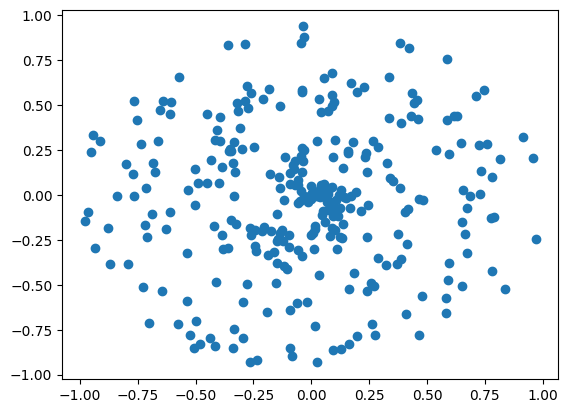

In [69]:
import numpy as np
import nnfs
nnfs.init()
import matplotlib.pyplot as plt
X,y = spiral_data(samples=100,classes=3)
plt.scatter(X[:,0],X[:,1])
plt.show()

In [70]:
X.shape

(300, 2)

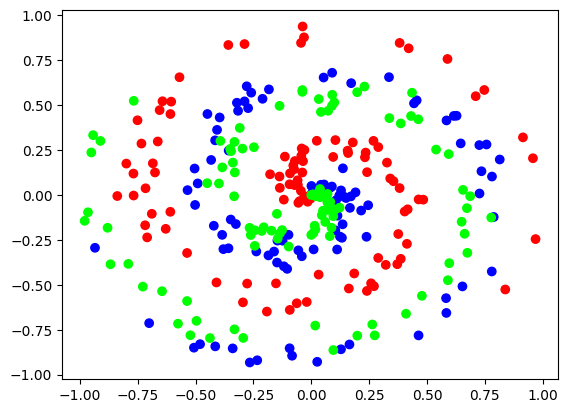

In [71]:
plt.scatter(X[:,0],X[:,1],c=y, cmap='brg')

**The neural network will not be aware of the color differences as the data have no class encodings**
# DENSE LAYER

In [72]:

class Layer_Dense:
  # Layer initialization
  def __init__(self,n_inputs,n_neurons):
    self.weights = 0.01 * np.random.randn(n_inputs,n_neurons)
    self.biases = np.zeros((1,n_neurons))

  # forward pass
  def forward(self,inputs):
    #  calculate the output values from input weights and biases
    self.output = np.dot(inputs,self.weights)+self.biases

# Craewte dataset
X,y = spiral_data(samples=100,classes=3)
# Creawte the Dense layer with two input features and 3 outps since teh calsses in the circle are theree
dense1 = Layer_Dense(2,3)
# perform a forward pass of our training data through this layer
dense1.forward(X)

# lets see the output
print(dense1.output[:5])


[[ 0.00000000e+00  0.00000000e+00  0.00000000e+00]
 [-1.11171044e-04 -5.11007493e-05 -1.12099799e-04]
 [ 2.99257295e-06 -2.69126613e-04 -1.45165104e-04]
 [ 8.95101766e-05 -4.30442247e-04 -1.68079801e-04]
 [-3.49893759e-04 -3.07208364e-04 -4.33002861e-04]]


In [73]:
np.zeros((1,10))

array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]], dtype=float32)

In [74]:
inputs = [[0,2,-1,4.4,5,7,8,-100],
          [3,5,-1,-500,5,5,4,3,]]
output = []
output = np.maximum(0,inputs)
print(output)

[[0.  2.  0.  4.4 5.  7.  8.  0. ]
 [3.  5.  0.  0.  5.  5.  4.  3. ]]


In [75]:
# relu activation functions (0,x)
class Activation_Relu:
  def forward(self,inputs):
    self.output = np.maximum(0,inputs)

In [76]:
# create the dataset

X,y = spiral_data(samples=100,classes=3)

dense2 = Layer_Dense(2,3)
activation = Activation_Relu()
dense2.forward(X)
activation.forward(dense2.output)
print(activation.output[:5])

[[0.0000000e+00 0.0000000e+00 0.0000000e+00]
 [1.3520580e-04 1.8173116e-05 0.0000000e+00]
 [2.3245417e-04 0.0000000e+00 0.0000000e+00]
 [3.8226307e-04 0.0000000e+00 0.0000000e+00]
 [5.7436468e-04 0.0000000e+00 0.0000000e+00]]


In [77]:
np.sum(dense2.output,axis=1,keepdims=True).shape,dense2.output.shape

((300, 1), (300, 3))

In [78]:
# SoftMax Activation function
class Activation_Softmax:
  # fprward pass
  def forward(self,input):
    exp_values = np.exp(input - np.max(input,axis=1,keepdims=True))#for outliers
    probabilities = exp_values / np.sum(exp_values,axis=1,keepdims=True)
    self.output = probabilities

In [79]:

class Layer_Dense:
  # Layer initialization
  def __init__(self,n_inputs,n_neurons):
    self.weights = 0.01 * np.random.randn(n_inputs,n_neurons)
    self.biases = np.zeros((1,n_neurons))

  # forward pass
  def forward(self,inputs):
    #  calculate the output values from input weights and biases
    self.output = np.dot(inputs,self.weights)+self.biases

# Craewte dataset
X,y = spiral_data(samples=100,classes=3)
# Creawte the Dense layer with two input features and 3 outps since teh calsses in the circle are theree
dense1 = Layer_Dense(2,3)
# perform a forward pass of our training data through this layer
dense1.forward(X)
activation1 = Activation_Relu()
activation1.forward(dense1.output)

# dense laeyer etwo andtivation softmax
dense2 = Layer_Dense(3,3)
activation2 = Activation_Softmax()
dense2.forward(activation1.output)
activation2.forward(dense2.output)
# lets see the output
print(dense2.output[:5])

[[ 0.0000000e+00  0.0000000e+00  0.0000000e+00]
 [-1.1500746e-07  5.4550026e-07  2.3433664e-07]
 [-5.1198003e-07  2.2910278e-06  1.9911435e-07]
 [-2.1754120e-06  6.0880016e-06 -1.1488704e-06]
 [-2.6458404e-06  8.1398202e-06 -9.9505928e-07]]


**Calculate Network Error With Loss**
CROSS ENTROPY LOSS BUILDING BLOCKS IN PYTHON

In [80]:
softmax_outputs = np.array([[0.7,0.1,0.2],
 [0.1,0.5,0.4],
  [0.02,0.9,0.08]])
class_targets = np.array([0,1,1])
print(softmax_outputs)

[[0.7  0.1  0.2 ]
 [0.1  0.5  0.4 ]
 [0.02 0.9  0.08]]


In [81]:
range(len(softmax_outputs))

range(0, 3)

In [82]:
print(-np.log(softmax_outputs[
    range(len(softmax_outputs)),class_targets
]))
neg_log = -np.log(softmax_outputs[range(len(softmax_outputs)),class_targets])
average_loss = np.mean(neg_log)
print(average_loss)

[0.35667494 0.69314718 0.10536052]
0.38506088005216804


IF DATA IS ONE HOT ENCODED THEN HOW TO EXTRACT THE RELEVENT PROBABILIITES


In [83]:
y_true_check = np.array([
    [1,0,0],
    [0,1,0],
    [0,1,0]
])

y_preds_clipped_check = np.array([
    [0.7, 0.2, 0.1],
    [0.1, 0.5, 0.4],
    [0.02, 0.9, 0.08]
])

A = y_true_check * y_preds_clipped_check
"""
Where 1 is the label in trainig the only probabilites matter that is why we need the product
[[0.7 0.  0. ]
 [0.  0.5 0. ]
 [0.  0.9 0. ]]
 """
B = np.sum(A,axis=1)
C = -np.log(B)
print(B)
print(C)
print(np.mean(C))

[0.7 0.5 0.9]
[0.35667494 0.69314718 0.10536052]
0.38506088005216804


**Notice what happens: why we use log to the probabilites if probability is 1 and input label is also 1 then loss should be log(1) = 0 which is why we take log here**

High confidence and correct → very small loss.
Low confidence → loss grows rapidly.
Extremely wrong predictions get punished much more.

**This is exactly what we want during training.**

In [84]:
# Common loss class
class Loss:
 # Calculates the data and regularization losses
 # given model output and ground truth values
 def calculate(self, output, y):
  # Calculate sample losses
  sample_losses = self.forward(output, y)
  # Calculate mean loss
  data_loss = np.mean(sample_losses)
  # Return loss
  return data_loss

In [85]:
# Cross-entropy loss
class Loss_CategoricalCrossentropy(Loss):
 # Forward pass
 def forward(self, y_pred, y_true):
  # Number of samples in a batch
  samples = len(y_pred)
  # Clip data to prevent division by 0
  # Clip both sides to not drag mean towards any value
  y_pred_clipped = np.clip(y_pred, 1e-7, 1 - 1e-7)
  # Probabilities for target values -
  # only if categorical labels
  if len(y_true.shape) == 1:
   correct_confidences = y_pred_clipped[
   range(samples),
   y_true
   ]
  # Mask values - only for one-hot encoded labels
  elif len(y_true.shape) == 2:
   correct_confidences = np.sum(
   y_pred_clipped*y_true,
   axis=1
   )
 # Losses
  negative_log_likelihoods = -np.log(correct_confidences)
  return negative_log_likelihoods

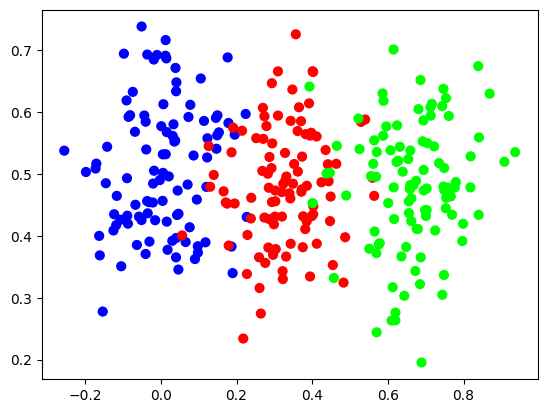

In [86]:
#SIMPLER DATASET
import matplotlib.pyplot as plt
import nnfs
from nnfs.datasets import vertical_data
nnfs.init()
X, y = vertical_data(samples=100, classes=3)
plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap='brg')
plt.show()

In [88]:
# Create dataset
X, y = vertical_data(samples=100, classes=3)
# Create model
dense1 = Layer_Dense(2, 3) # first dense layer, 2 inputs
activation1 = Activation_Relu()
dense2 = Layer_Dense(3, 3) # second dense layer, 3 inputs, 3 outputs
activation2 = Activation_Softmax()
# Create loss function
loss_function = Loss_CategoricalCrossentropy()

# Helper variables
lowest_loss = 9999999 # some initial value
best_dense1_weights = dense1.weights.copy()
best_dense1_biases = dense1.biases.copy()
best_dense2_weights = dense2.weights.copy()
best_dense2_biases = dense2.biases.copy()

for iteration in range(100000):
 # Generate a new set of weights for iteration
 dense1.weights = 0.05 * np.random.randn(2, 3)
 dense1.biases = 0.05 * np.random.randn(1, 3)
 dense2.weights = 0.05 * np.random.randn(3, 3)
 dense2.biases = 0.05 * np.random.randn(1, 3)
 # Perform a forward pass of the training data through this layer
 dense1.forward(X)
 activation1.forward(dense1.output)
 dense2.forward(activation1.output)
 activation2.forward(dense2.output)
 # Perform a forward pass through activation function
 # it takes the output of second dense layer here and returns loss
 loss = loss_function.calculate(activation2.output, y)
 # Calculate accuracy from output of activation2 and targets
 # calculate values along first axis
 predictions = np.argmax(activation2.output, axis=1)
 accuracy = np.mean(predictions == y)
 # If loss is smaller - print and save weights and biases aside
 if loss < lowest_loss:
   print('New set of weights found, iteration:', iteration,'loss:', loss, 'acc:', accuracy)
   best_dense1_weights = dense1.weights.copy()
   best_dense1_biases = dense1.biases.copy()
   best_dense2_weights = dense2.weights.copy()
   best_dense2_biases = dense2.biases.copy()
   lowest_loss = loss

New set of weights found, iteration: 0 loss: 1.1000165 acc: 0.3333333333333333
New set of weights found, iteration: 1 loss: 1.0982995 acc: 0.3333333333333333
New set of weights found, iteration: 12 loss: 1.0982885 acc: 0.3333333333333333
New set of weights found, iteration: 18 loss: 1.0982664 acc: 0.3333333333333333
New set of weights found, iteration: 24 loss: 1.0982476 acc: 0.3333333333333333
New set of weights found, iteration: 49 loss: 1.098012 acc: 0.3333333333333333
New set of weights found, iteration: 150 loss: 1.0979943 acc: 0.3333333333333333
New set of weights found, iteration: 154 loss: 1.0976987 acc: 0.3333333333333333
New set of weights found, iteration: 236 loss: 1.0971556 acc: 0.3333333333333333
New set of weights found, iteration: 1353 loss: 1.096727 acc: 0.3333333333333333
New set of weights found, iteration: 2055 loss: 1.0967029 acc: 0.3333333333333333
New set of weights found, iteration: 4775 loss: 1.0958736 acc: 0.3333333333333333
New set of weights found, iteration

In [91]:
# Create dataset
X, y = vertical_data(samples=100, classes=3)
# Create model
dense1 = Layer_Dense(2, 3) # first dense layer, 2 inputs
activation1 = Activation_Relu()
dense2 = Layer_Dense(3, 3) # second dense layer, 3 inputs, 3 outputs
activation2 = Activation_Softmax()
# Create loss function
loss_function = Loss_CategoricalCrossentropy()
# Helper variables
lowest_loss = 9999999 # some initial value
best_dense1_weights = dense1.weights.copy()
best_dense1_biases = dense1.biases.copy()
best_dense2_weights = dense2.weights.copy()
best_dense2_biases = dense2.biases.copy()
for iteration in range(10000):
 # Update weights with some small random values
 dense1.weights += 0.05 * np.random.randn(2, 3)
 dense1.biases += 0.05 * np.random.randn(1, 3)
 dense2.weights += 0.05 * np.random.randn(3, 3)
 dense2.biases += 0.05 * np.random.randn(1, 3)
 # Perform a forward pass of our training data through this layer
 dense1.forward(X)
 activation1.forward(dense1.output)
 dense2.forward(activation1.output)
 activation2.forward(dense2.output)
 # Perform a forward pass through activation function
 # it takes the output of second dense layer here and returns loss
 loss = loss_function.calculate(activation2.output, y)
 # Calculate accuracy from output of activation2 and targets
 # calculate values along first axis
 predictions = np.argmax(activation2.output, axis=1)
 accuracy = np.mean(predictions == y)
 # If loss is smaller - print and save weights and biases aside
 if loss < lowest_loss:
  print('New set of weights found, iteration:', iteration,'loss:', loss, 'acc:', accuracy)
  best_dense1_weights = dense1.weights.copy()
  best_dense1_biases = dense1.biases.copy()
  best_dense2_weights = dense2.weights.copy()
  best_dense2_biases = dense2.biases.copy()
  lowest_loss = loss
 # Revert weights and biases
 else:
  dense1.weights = best_dense1_weights.copy()
  dense1.biases = best_dense1_biases.copy()
  dense2.weights = best_dense2_weights.copy()
  dense2.biases = best_dense2_biases.copy()

New set of weights found, iteration: 0 loss: 1.0991429 acc: 0.3333333333333333
New set of weights found, iteration: 2 loss: 1.098534 acc: 0.3333333333333333
New set of weights found, iteration: 8 loss: 1.0981379 acc: 0.3333333333333333
New set of weights found, iteration: 9 loss: 1.0971631 acc: 0.3333333333333333
New set of weights found, iteration: 12 loss: 1.0971221 acc: 0.3333333333333333
New set of weights found, iteration: 14 loss: 1.0945274 acc: 0.5433333333333333
New set of weights found, iteration: 20 loss: 1.0903894 acc: 0.6033333333333334
New set of weights found, iteration: 22 loss: 1.0854189 acc: 0.4633333333333333
New set of weights found, iteration: 24 loss: 1.0801213 acc: 0.5933333333333334
New set of weights found, iteration: 25 loss: 1.0794865 acc: 0.44666666666666666
New set of weights found, iteration: 29 loss: 1.07178 acc: 0.6166666666666667
New set of weights found, iteration: 33 loss: 1.0693998 acc: 0.3333333333333333
New set of weights found, iteration: 35 loss: 

In [93]:
# Create dataset
X, y = spiral_data(samples=100, classes=3)# Create model
dense1 = Layer_Dense(2, 3) # first dense layer, 2 inputs
activation1 = Activation_Relu()
dense2 = Layer_Dense(3, 3) # second dense layer, 3 inputs, 3 outputs
activation2 = Activation_Softmax()
# Create loss function
loss_function = Loss_CategoricalCrossentropy()
# Helper variables
lowest_loss = 9999999 # some initial value
best_dense1_weights = dense1.weights.copy()
best_dense1_biases = dense1.biases.copy()
best_dense2_weights = dense2.weights.copy()
best_dense2_biases = dense2.biases.copy()
for iteration in range(10000):
 # Update weights with some small random values
 dense1.weights += 0.05 * np.random.randn(2, 3)
 dense1.biases += 0.05 * np.random.randn(1, 3)
 dense2.weights += 0.05 * np.random.randn(3, 3)
 dense2.biases += 0.05 * np.random.randn(1, 3)
 # Perform a forward pass of our training data through this layer
 dense1.forward(X)
 activation1.forward(dense1.output)
 dense2.forward(activation1.output)
 activation2.forward(dense2.output)
 # Perform a forward pass through activation function
 # it takes the output of second dense layer here and returns loss
 loss = loss_function.calculate(activation2.output, y)
 # Calculate accuracy from output of activation2 and targets
 # calculate values along first axis
 predictions = np.argmax(activation2.output, axis=1)
 accuracy = np.mean(predictions == y)
 # If loss is smaller - print and save weights and biases aside
 if loss < lowest_loss:
  print('New set of weights found, iteration:', iteration,'loss:', loss, 'acc:', accuracy)
  best_dense1_weights = dense1.weights.copy()
  best_dense1_biases = dense1.biases.copy()
  best_dense2_weights = dense2.weights.copy()
  best_dense2_biases = dense2.biases.copy()
  lowest_loss = loss
 # Revert weights and biases
 else:
  dense1.weights = best_dense1_weights.copy()
  dense1.biases = best_dense1_biases.copy()
  dense2.weights = best_dense2_weights.copy()
  dense2.biases = best_dense2_biases.copy()

New set of weights found, iteration: 0 loss: 1.0985173 acc: 0.3333333333333333
New set of weights found, iteration: 33 loss: 1.0982707 acc: 0.3333333333333333
New set of weights found, iteration: 34 loss: 1.0978147 acc: 0.3333333333333333
New set of weights found, iteration: 38 loss: 1.0974957 acc: 0.36333333333333334
New set of weights found, iteration: 46 loss: 1.0962383 acc: 0.36333333333333334
New set of weights found, iteration: 52 loss: 1.0959065 acc: 0.35
New set of weights found, iteration: 55 loss: 1.0949205 acc: 0.37
New set of weights found, iteration: 56 loss: 1.0938596 acc: 0.36333333333333334
New set of weights found, iteration: 57 loss: 1.0912181 acc: 0.38
New set of weights found, iteration: 58 loss: 1.0909634 acc: 0.36
New set of weights found, iteration: 63 loss: 1.0902898 acc: 0.4033333333333333
New set of weights found, iteration: 67 loss: 1.0900612 acc: 0.37333333333333335
New set of weights found, iteration: 71 loss: 1.0885085 acc: 0.41333333333333333
New set of w